In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
%pip install torch transformers
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer, 
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.optim import AdamW

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder

In [5]:
import os
import sys
import warnings
import joblib
import json
from pathlib import Path
from datetime import datetime
import time

In [6]:
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

🚀 Using device: cpu


In [8]:
PROJECT_ROOT = Path().absolute().parent
DATA_PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'processed_reviews.csv'
ARTIFACTS_PATH = PROJECT_ROOT / 'artifacts'
MODELS_PATH = ARTIFACTS_PATH / 'models'
TOKENIZERS_PATH = ARTIFACTS_PATH / 'tokenizers'
ENCODERS_PATH = ARTIFACTS_PATH / 'encoders'
METRICS_PATH = ARTIFACTS_PATH / 'metrics'

In [9]:
DATA_PROCESSED_PATH

PosixPath('/Users/msquaremac/Trendify_Sentiment/data/processed/processed_reviews.csv')

In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
# DATA_PROCESSED_PATH = "/content/drive/MyDrive/processed_reviews.csv"
# df = pd.read_csv(DATA_PROCESSED_PATH)

In [12]:
df = pd.read_csv(DATA_PROCESSED_PATH)
print(f"Loaded {len(df)} samples")
print(f"Shape: {df.shape}")

Loaded 30000 samples
Shape: (30000, 9)


In [13]:
sentiment_dist = df['sentiment'].value_counts()
for sentiment, count in sentiment_dist.items():
    print(f"   {sentiment}: {count} ({count/len(df)*100:.1f}%)")

   positive: 10000 (33.3%)
   neutral: 10000 (33.3%)
   negative: 10000 (33.3%)


In [14]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])
num_classes = len(label_encoder.classes_)

print(f"\n🎯 Classes: {label_encoder.classes_}")
print(f"   Mapping: {dict(zip(label_encoder.classes_, range(num_classes)))}")


🎯 Classes: ['negative' 'neutral' 'positive']
   Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [15]:
# ENCODERS_PATH = Path("/content/drive/MyDrive/models/encoders")
# ENCODERS_PATH.mkdir(parents=True, exist_ok=True)

In [16]:
joblib.dump(label_encoder, ENCODERS_PATH / 'distilbert_label_encoder.pkl')

['/Users/msquaremac/Trendify_Sentiment/artifacts/encoders/distilbert_label_encoder.pkl']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label'],
    shuffle=True
)

In [18]:
y_train

8348     1
18866    2
22156    1
26693    2
15301    2
        ..
13437    1
24782    0
11933    1
2843     1
27173    1
Name: label, Length: 24000, dtype: int64

In [19]:
print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining distribution:")
for i, class_name in enumerate(label_encoder.classes_):
    count = sum(y_train == i)
    print(f"   {class_name}: {count} ({count/len(y_train)*100:.1f}%)")


Training set: 24000 samples
Test set: 6000 samples

Training distribution:
   negative: 8000 (33.3%)
   neutral: 8000 (33.3%)
   positive: 8000 (33.3%)


In [20]:
class SentimentDataset(Dataset):
    """Custom Dataset for sentiment analysis"""
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [21]:
model_name = 'distilbert-base-multilingual-cased'

In [22]:
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

In [23]:
# TOKENIZERS_PATH = Path("/content/drive/MyDrive/models/tokenizers")
# TOKENIZERS_PATH.mkdir(parents=True, exist_ok=True)

In [24]:
tokenizer.save_pretrained(TOKENIZERS_PATH / 'distilbert_tokenizer')

('/Users/msquaremac/Trendify_Sentiment/artifacts/tokenizers/distilbert_tokenizer/tokenizer_config.json',
 '/Users/msquaremac/Trendify_Sentiment/artifacts/tokenizers/distilbert_tokenizer/tokenizer.json')

In [25]:
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes
)
model = model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 18525.26it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

   Total parameters: 135,326,979
   Trainable parameters: 135,326,979


In [27]:
MAX_LENGTH = 128
BATCH_SIZE = 16

In [28]:
train_dataset = SentimentDataset(X_train, y_train, tokenizer, MAX_LENGTH)
test_dataset = SentimentDataset(X_test, y_test, tokenizer, MAX_LENGTH)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"\n✅ Training batches: {len(train_loader)}")
print(f"✅ Test batches: {len(test_loader)}")


✅ Training batches: 1500
✅ Test batches: 375


In [29]:
EPOCHS = 3
LEARNING_RATE = 2e-5

In [30]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

In [31]:
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Loss function
criterion = torch.nn.CrossEntropyLoss()

In [32]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []
    
    for batch_idx, batch in enumerate(data_loader):
        # Move to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Store predictions
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
        
        # Print progress
        if (batch_idx + 1) % 50 == 0:
            print(f"      Batch {batch_idx + 1}/{len(data_loader)} - Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)
    
    return avg_loss, accuracy

In [33]:
def evaluate(model, data_loader, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')
    
    return avg_loss, accuracy, f1, predictions, true_labels

In [34]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_val_f1 = 0
best_model_state = None

In [35]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)
    
    # Train
    start_time = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    train_time = time.time() - start_time
    
    # Evaluate
    val_loss, val_acc, val_f1, val_preds, val_true = evaluate(model, test_loader, device)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"\n   Training - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}, Time: {train_time:.1f}s")
    print(f"   Validation - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
        print(f"   ✨ New best model! F1: {val_f1:.4f}")

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"\n✅ Loaded best model with F1: {best_val_f1:.4f}")


Epoch 1/3
----------------------------------------
      Batch 50/1500 - Loss: 1.0814
      Batch 100/1500 - Loss: 1.0322
      Batch 150/1500 - Loss: 0.8822
      Batch 200/1500 - Loss: 0.3106
      Batch 250/1500 - Loss: 0.0328
      Batch 300/1500 - Loss: 0.0112
      Batch 350/1500 - Loss: 0.0054
      Batch 400/1500 - Loss: 0.0038
      Batch 450/1500 - Loss: 0.0023
      Batch 500/1500 - Loss: 0.0019
      Batch 550/1500 - Loss: 0.0012
      Batch 600/1500 - Loss: 0.0011
      Batch 650/1500 - Loss: 0.0010
      Batch 700/1500 - Loss: 0.0008
      Batch 750/1500 - Loss: 0.0007
      Batch 800/1500 - Loss: 0.0007
      Batch 850/1500 - Loss: 0.0005
      Batch 900/1500 - Loss: 0.0004
      Batch 950/1500 - Loss: 0.0004
      Batch 1000/1500 - Loss: 0.0003
      Batch 1050/1500 - Loss: 0.0003
      Batch 1100/1500 - Loss: 0.0003
      Batch 1150/1500 - Loss: 0.0003
      Batch 1200/1500 - Loss: 0.0004
      Batch 1250/1500 - Loss: 0.0003
      Batch 1300/1500 - Loss: 0.0002
      

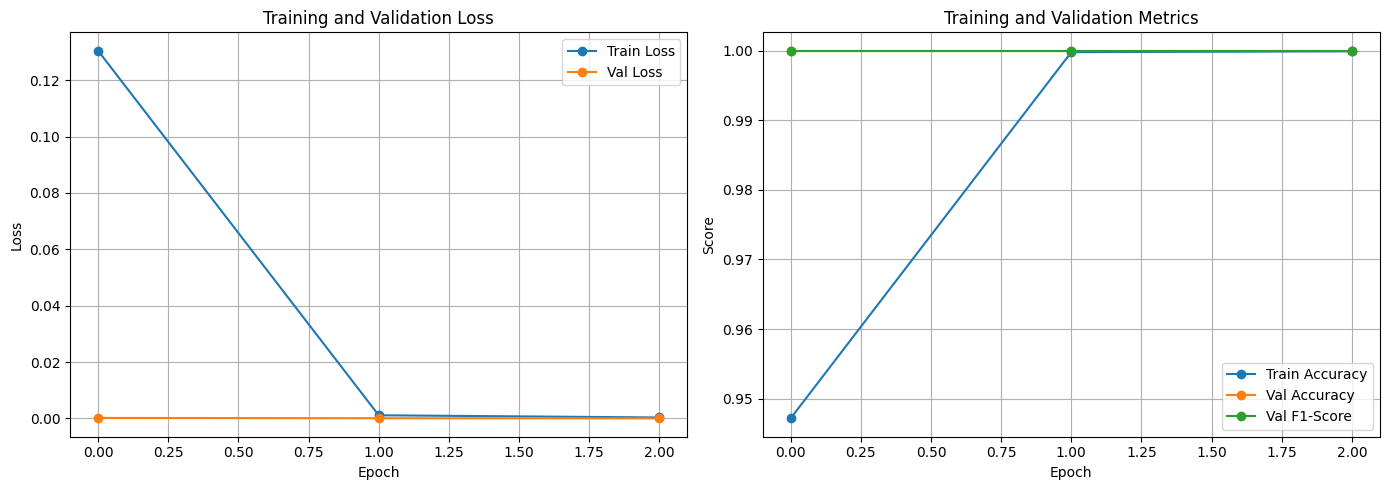

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1].plot(history['val_f1'], label='Val F1-Score', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Training and Validation Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('distilbert_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
final_loss, final_acc, final_f1, final_preds, final_true = evaluate(model, test_loader, device)

print(f"\nTest Set Performance:")
print(f"   Loss: {final_loss:.4f}")
print(f"   Accuracy: {final_acc:.4f}")
print(f"   F1-Score (macro): {final_f1:.4f}")


Test Set Performance:
   Loss: 0.0000
   Accuracy: 1.0000
   F1-Score (macro): 1.0000


In [38]:
print("\nClassification Report:")
print(classification_report(final_true, final_preds, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(final_true, final_preds)

fig = px.imshow(
    cm,
    x=label_encoder.classes_,
    y=label_encoder.classes_,
    text_auto=True,
    color_continuous_scale='Purples',
    title='Confusion Matrix - DistilBERT'
)
fig.update_layout(height=500, width=500)
fig.show()


Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      2000
     neutral       1.00      1.00      1.00      2000
    positive       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [39]:
precision = precision_score(final_true, final_preds, average=None)
recall = recall_score(final_true, final_preds, average=None)
f1_per_class = f1_score(final_true, final_preds, average=None)

per_class_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_per_class,
    # 'Support': [sum(final_true == i) for i in range(num_classes)]
})


In [40]:
fig = go.Figure(data=[
    go.Bar(name='Precision', x=per_class_df['Class'], y=per_class_df['Precision'], 
           text=per_class_df['Precision'].round(3), textposition='auto'),
    go.Bar(name='Recall', x=per_class_df['Class'], y=per_class_df['Recall'],
           text=per_class_df['Recall'].round(3), textposition='auto'),
    go.Bar(name='F1-Score', x=per_class_df['Class'], y=per_class_df['F1-Score'],
           text=per_class_df['F1-Score'].round(3), textposition='auto')
])

fig.update_layout(
    title='Per-Class Performance Metrics',
    xaxis_title='Sentiment Class',
    yaxis_title='Score',
    barmode='group',
    yaxis_range=[0, 1],
    height=400
)
fig.show()

In [41]:
test_texts = X_test.reset_index(drop=True)
error_df = pd.DataFrame({
    'text': test_texts,
    'true_label': label_encoder.inverse_transform(final_true),
    'predicted_label': label_encoder.inverse_transform(final_preds),
    'correct': final_true == final_preds
})

misclassified = error_df[~error_df['correct']]

print("\n" + "="*60)
print("ERROR ANALYSIS")

print(f"\nTotal misclassifications: {len(misclassified)} ({len(misclassified)/len(error_df)*100:.1f}%)")

if len(misclassified) > 0:
    print("\n🔍 Sample misclassifications:")
    for idx, row in misclassified.head(10).iterrows():
        print(f"\n   True: {row['true_label']} | Pred: {row['predicted_label']}")
        print(f"   Text: {row['text'][:150]}...")
    
    # Confusion patterns
    print("\n📊 Confusion patterns:")
    confusion_pairs = misclassified.groupby(['true_label', 'predicted_label']).size().sort_values(ascending=False)
    for (true, pred), count in confusion_pairs.head().items():
        print(f"   {true} → {pred}: {count} cases")


ERROR ANALYSIS

Total misclassifications: 0 (0.0%)


In [42]:
# MODELS_PATH = Path("/content/drive/MyDrive/models/BERT")
# MODELS_PATH.mkdir(parents=True, exist_ok=True)

In [43]:
model_save_path = MODELS_PATH / 'distilbert_model'
model.save_pretrained(model_save_path)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.46it/s]


In [44]:
tokenizer.save_pretrained(TOKENIZERS_PATH / 'distilbert_tokenizer')

('/Users/msquaremac/Trendify_Sentiment/artifacts/tokenizers/distilbert_tokenizer/tokenizer_config.json',
 '/Users/msquaremac/Trendify_Sentiment/artifacts/tokenizers/distilbert_tokenizer/tokenizer.json')

In [45]:
# METRICS_PATH = Path("/content/drive/MyDrive/models/METRICS")
# METRICS_PATH.mkdir(parents=True, exist_ok=True)

In [46]:
results = {
    'model_name': 'distilbert-base-multilingual-cased',
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'device': str(device),
    'num_epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'max_length': MAX_LENGTH,
    'dataset_info': {
        'total_samples': len(df),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'num_classes': num_classes,
        'classes': label_encoder.classes_.tolist()
    },
    'performance': {
        'test_loss': float(final_loss),
        'test_accuracy': float(final_acc),
        'test_f1_macro': float(final_f1),
        'per_class_precision': precision.tolist(),
        'per_class_recall': recall.tolist(),
        'per_class_f1': f1_per_class.tolist()
    },
    'confusion_matrix': cm.tolist(),
    'training_history': history
}

with open(METRICS_PATH / 'distilbert_results.json', 'w') as f:
    json.dump(results, f, indent=4)

In [47]:
def predict_sentiment(text, model=None, tokenizer=None, label_encoder=None, device='cpu'):
    """
    Predict sentiment for a single text or list of texts
    """
    if model is None:
        # Load model
        model = DistilBertForSequenceClassification.from_pretrained(
            MODELS_PATH / 'distilbert_model'
        ).to(device)
        model.eval()
    
    if tokenizer is None:
        tokenizer = DistilBertTokenizer.from_pretrained(
            TOKENIZERS_PATH / 'distilbert_tokenizer'
        )
    
    if label_encoder is None:
        label_encoder = joblib.load(ENCODERS_PATH / 'distilbert_label_encoder.pkl')
    
    # Handle single text or list
    if isinstance(text, str):
        texts = [text]
        single = True
    else:
        texts = text
        single = False
    
    # Tokenize
    inputs = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=1)
        predictions = torch.argmax(outputs.logits, dim=1)
    
    # Convert to labels
    pred_labels = label_encoder.inverse_transform(predictions.cpu().numpy())
    probs = probabilities.cpu().numpy()
    
    if single:
        return pred_labels[0], dict(zip(label_encoder.classes_, probs[0]))
    else:
        return pred_labels, [dict(zip(label_encoder.classes_, p)) for p in probs]

In [48]:
def predict_sentiment(text, model=None, tokenizer=None, label_encoder=None, device='cpu'):
    
    if model is None:
        model = DistilBertForSequenceClassification.from_pretrained(
            MODELS_PATH / 'distilbert_model'
        ).to(device)
        model.eval()

    if tokenizer is None:
        tokenizer = DistilBertTokenizer.from_pretrained(
            TOKENIZERS_PATH / 'distilbert_tokenizer'
        )

    if label_encoder is None:
        label_encoder = joblib.load(
            ENCODERS_PATH / 'distilbert_label_encoder.pkl'
        )

    # Handle input format
    if isinstance(text, str):
        texts = [text]
        single = True
    else:
        texts = text
        single = False

    inputs = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=1)

    predictions = torch.argmax(probabilities, dim=1)

    pred_labels = label_encoder.inverse_transform(predictions.cpu().numpy())
    probs = probabilities.cpu().numpy()

    if single:
        return pred_labels[0], dict(zip(label_encoder.classes_, probs[0]))
    else:
        return pred_labels, [
            dict(zip(label_encoder.classes_, p)) for p in probs
        ]

In [49]:
test_examples = [
    "This product is amazing! I absolutely love it. Best purchase ever!",
    "Terrible quality, broke after one use. Very disappointed.",
    "It's okay for the price, nothing special but works as expected.",
    "Ich liebe dieses Produkt! Es ist fantastisch!",
    "C'est un très bon produit, je le recommande.",
    "Estoy muy satisfecho con mi compra."
]

print("\n🔍 Testing multilingual examples:")
for i, example in enumerate(test_examples, 1):
    sentiment, probs = predict_sentiment(example)
    print(f"\n{i}. Text: {example[:50]}...")
    print(f"   Predicted: {sentiment}")
    print(f"   Confidence: {max(probs.values()):.3f}")
    print(f"   Probabilities: {probs}")


🔍 Testing multilingual examples:


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 19939.10it/s]



1. Text: This product is amazing! I absolutely love it. Bes...
   Predicted: positive
   Confidence: 1.000
   Probabilities: {'negative': np.float32(8.741173e-06), 'neutral': np.float32(1.08095555e-05), 'positive': np.float32(0.99998045)}


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 27382.78it/s]



2. Text: Terrible quality, broke after one use. Very disapp...
   Predicted: negative
   Confidence: 1.000
   Probabilities: {'negative': np.float32(0.99997795), 'neutral': np.float32(9.758892e-06), 'positive': np.float32(1.22534275e-05)}


...


4. Text: Ich liebe dieses Produkt! Es ist fantastisch!...
   Predicted: positive
   Confidence: 1.000
   Probabilities: {'negative': np.float32(1.0209317e-05), 'neutral': np.float32(1.2139228e-05), 'positive': np.float32(0.9999777)}


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 28229.85it/s]



5. Text: C'est un très bon produit, je le recommande....
   Predicted: positive
   Confidence: 1.000
   Probabilities: {'negative': np.float32(7.639086e-06), 'neutral': np.float32(2.328145e-05), 'positive': np.float32(0.9999691)}


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 28735.68it/s]



6. Text: Estoy muy satisfecho con mi compra....
   Predicted: positive
   Confidence: 1.000
   Probabilities: {'negative': np.float32(8.562647e-06), 'neutral': np.float32(1.13272545e-05), 'positive': np.float32(0.9999801)}
